# Questão 3: Árvore Geradora Mínima — Kruskal vs. Prim

Este notebook compara empiricamente o desempenho dos algoritmos de **Kruskal** e **Prim** 
na construção da Árvore Geradora Mínima (MST) de um grafo, variando:
- o **número de vértices** ($V$);
- a **densidade** do grafo (esparso vs. denso);
- múltiplas **sementes** (seeds) de geração aleatória, para reduzir viés estatístico.

A geração dos grafos e a execução dos algoritmos são feitas por um programa em **C++** 
(`generator.cpp`), escolhido pela performance, enquanto o **Python** é usado para 
orquestrar as execuções, coletar os tempos e gerar as visualizações.

### Compilação do Gerador em C++

O primeiro passo é compilar o executável responsável por gerar os grafos e rodar 
Kruskal/Prim de forma nativa (evitando o overhead de implementações em Python 
para grafos grandes).

In [3]:
import os
import sys

# Define a extensão correta de acordo com o sistema operacional
extensao = ""
nome_executavel = f"generator{extensao}"

print(f"Compilando o código C++ para {nome_executavel}...")
compile_cmd = f"g++ generator.cpp -o {nome_executavel}"
resultado = os.system(compile_cmd)

if resultado == 0:
    print("Compilação concluída com sucesso!")
else:
    print("Erro durante a compilação. Certifique-se de que o g++ está configurado no seu PATH.")

Compilando o código C++ para generator...
Compilação concluída com sucesso!


### Execução do Gerador e Leitura dos Resultados

A função `executar_e_parsear` chama o executável C++ passando `vertices`, `is_dense` 
e `seed` como argumentos. O programa gera o grafo já representado como **matriz de 
adjacência** e roda, sobre essa mesma representação:

- **Kruskal**, extraindo as arestas da matriz e ordenando-as;
- **Prim**, usando **busca linear (naive)** a cada iteração para encontrar a aresta 
  de menor peso que conecta a árvore em construção ao restante do grafo — sem uso de 
  fila de prioridades (heap).

O resultado é gravado em um arquivo `.json` em `grafos/`, contendo a matriz original, 
as árvores geradoras resultantes de cada algoritmo e seus respectivos tempos de 
execução, que essa função lê e organiza para a plotagem e análise.

In [4]:
import subprocess
import sys
import json
import os

def executar_e_parsear(vertices, is_dense, seed):
    extensao = ".exe" if sys.platform == "win32" else ""
    cmd_executavel = f"./generator{extensao}"

    argumentos = [cmd_executavel, str(vertices), str(is_dense), str(seed)]
    resultado = subprocess.run(argumentos, capture_output=True)

    if resultado.returncode != 0:
        print(f"AVISO: O executável C++ retornou erro.")
        return {}, {}

    # Monta o caminho do arquivo JSON gerado
    density = "dense" if int(is_dense) else "sparse"
    json_path = f"grafos/graph_V{vertices}_{density}_S{seed}.json"

    if not os.path.exists(json_path):
        print(f"AVISO: Arquivo JSON não encontrado: {json_path}")
        return {}, {}

    with open(json_path, 'r') as f:
        data = json.load(f)

    # Monta o dicionário de grafos no formato esperado pelas funções de plotagem
    grafos = {
        "Original": data["graph"]["adjacency_matrix"],
        "Kruskal": data["kruskal"]["tree"],
        "Prim": data["prim"]["tree"]
    }

    tempos = {
        "Kruskal": data["kruskal"]["execution_time_ms"],
        "Prim": data["prim"]["execution_time_ms"]
    }

    return grafos, tempos


### Visualização dos Grafos

A função `plotar_resultados` desenha lado a lado o grafo **original** (representado 
internamente como matriz de adjacência) e as MSTs obtidas por **Kruskal** e por 
**Prim**, usando `networkx`. O layout dos nós é fixado (`seed=42`) para permitir 
comparação visual direta entre as três estruturas, e o tempo de execução de cada 
algoritmo é exibido no título do respectivo subplot.

In [5]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

def plotar_resultados(dados_grafos, tempos, vertices, subtitulo_tipo):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    algoritmos = ["Original", "Kruskal", "Prim"]
    
    pos_fixa = None
    
    for ax, chave in zip(axes, algoritmos):
        matriz = dados_grafos.get(chave, [])
        
        if not matriz or len(matriz) != vertices:
            ax.text(0.5, 0.5, f"Dados de [{chave}]\nnão encontrados ou incompletos.", 
                    ha='center', va='center', color='red', fontsize=11)
            ax.axis('off')
            continue
            
        matriz_np = np.array(matriz)
        G = nx.from_numpy_array(matriz_np)
        
        mapeamento_letras = {i: chr(ord('A') + i) for i in range(vertices)}
        G = nx.relabel_nodes(G, mapeamento_letras)
        
        if pos_fixa is None:
            pos_fixa = nx.spring_layout(G, seed=42)
            
        # Adiciona o tempo de execução no título, se for Kruskal ou Prim
        if chave in tempos:
            titulo = f"{subtitulo_tipo} - {chave}\nTempo: {tempos[chave]:.4f} ms"
        else:
            titulo = f"{subtitulo_tipo} - {chave}"
            
        ax.set_title(titulo, fontsize=13, fontweight='bold')
        
        arestas_ativas = [(u, v) for u, v, d in G.edges(data=True) if d['weight'] > 0]
        
        nx.draw_networkx_nodes(G, pos_fixa, ax=ax, node_color='lightgreen', node_size=500, edgecolors='black')
        nx.draw_networkx_labels(G, pos_fixa, ax=ax, font_size=10, font_weight='bold')
        nx.draw_networkx_edges(G, pos_fixa, ax=ax, edgelist=arestas_ativas, width=2.5, edge_color='teal')
        
        pesos_arestas = {(u, v): d['weight'] for u, v, d in G.edges(data=True) if d['weight'] > 0}
        nx.draw_networkx_edge_labels(G, pos_fixa, edge_labels=pesos_arestas, ax=ax, font_size=9)
        
        ax.axis('off')
        
    plt.tight_layout()
    plt.show()

### Experimento: Variação de Vértices, Densidade e Sementes

Para obter uma comparação estatisticamente robusta, o experimento varre:
- $V \in [2, 48]$ vértices;
- 30 sementes diferentes por tamanho de grafo;
- as duas densidades (esparso e denso).

Para cada combinação, o gerador é executado e os tempos de Kruskal e Prim são 
armazenados em `tempos_historico`, agrupados por densidade, algoritmo e número de vértices.

In [13]:
# Modifique os tamanhos e sementes conforme necessário
v = [c for c in range(1, 3000, 100)]
valores_vertices = v # [i for i in range(2, 1000, 10)]
sementes = [c for c in range(1)]

# Estrutura para armazenar os tempos e plotar o gráfico no final
tempos_historico = {
    "Esparso": {"Kruskal": {v: [] for v in valores_vertices}, "Prim": {v: [] for v in valores_vertices}},
    "Denso": {"Kruskal": {v: [] for v in valores_vertices}, "Prim": {v: [] for v in valores_vertices}}
}

for v in valores_vertices:
    for s in sementes:
        print(f"\n" + "="*70)
        print(f"PROCESSANDO: {v} VÉRTICES | SEED CONFIGURADA: {s}")
        print("="*70)
        
        # Execução e plot para a variação Esparsa
        print("\n-> Renderizando Estrutura Esparsa...")
        dados_esparso, tempos_esparso = executar_e_parsear(v, 0, s)
        #plotar_resultados(dados_esparso, tempos_esparso, v, "Grafo Esparso")
        
        # Guardando tempos
        if tempos_esparso:
            tempos_historico["Esparso"]["Kruskal"][v].append(tempos_esparso["Kruskal"])
            tempos_historico["Esparso"]["Prim"][v].append(tempos_esparso["Prim"])
        
        # Execução e plot para a variação Densa
        print("\n-> Renderizando Estrutura Densa...")
        dados_denso, tempos_denso = executar_e_parsear(v, 1, s)
        #plotar_resultados(dados_denso, tempos_denso, v, "Grafo Denso")
        
        # Guardando tempos
        if tempos_denso:
            tempos_historico["Denso"]["Kruskal"][v].append(tempos_denso["Kruskal"])
            tempos_historico["Denso"]["Prim"][v].append(tempos_denso["Prim"])


PROCESSANDO: 1 VÉRTICES | SEED CONFIGURADA: 0

-> Renderizando Estrutura Esparsa...

-> Renderizando Estrutura Densa...

PROCESSANDO: 101 VÉRTICES | SEED CONFIGURADA: 0

-> Renderizando Estrutura Esparsa...

-> Renderizando Estrutura Densa...

PROCESSANDO: 201 VÉRTICES | SEED CONFIGURADA: 0

-> Renderizando Estrutura Esparsa...

-> Renderizando Estrutura Densa...

PROCESSANDO: 301 VÉRTICES | SEED CONFIGURADA: 0

-> Renderizando Estrutura Esparsa...

-> Renderizando Estrutura Densa...

PROCESSANDO: 401 VÉRTICES | SEED CONFIGURADA: 0

-> Renderizando Estrutura Esparsa...

-> Renderizando Estrutura Densa...

PROCESSANDO: 501 VÉRTICES | SEED CONFIGURADA: 0

-> Renderizando Estrutura Esparsa...

-> Renderizando Estrutura Densa...

PROCESSANDO: 601 VÉRTICES | SEED CONFIGURADA: 0

-> Renderizando Estrutura Esparsa...

-> Renderizando Estrutura Densa...

PROCESSANDO: 701 VÉRTICES | SEED CONFIGURADA: 0

-> Renderizando Estrutura Esparsa...

-> Renderizando Estrutura Densa...

PROCESSANDO: 801 

### Comparação dos Tempos Médios de Execução

Com os dados coletados, calculamos a **média** dos tempos de execução por número de 
vértices e plotamos dois gráficos — um para grafos esparsos e outro para grafos 
densos — comparando diretamente Kruskal vs. Prim conforme o grafo cresce.

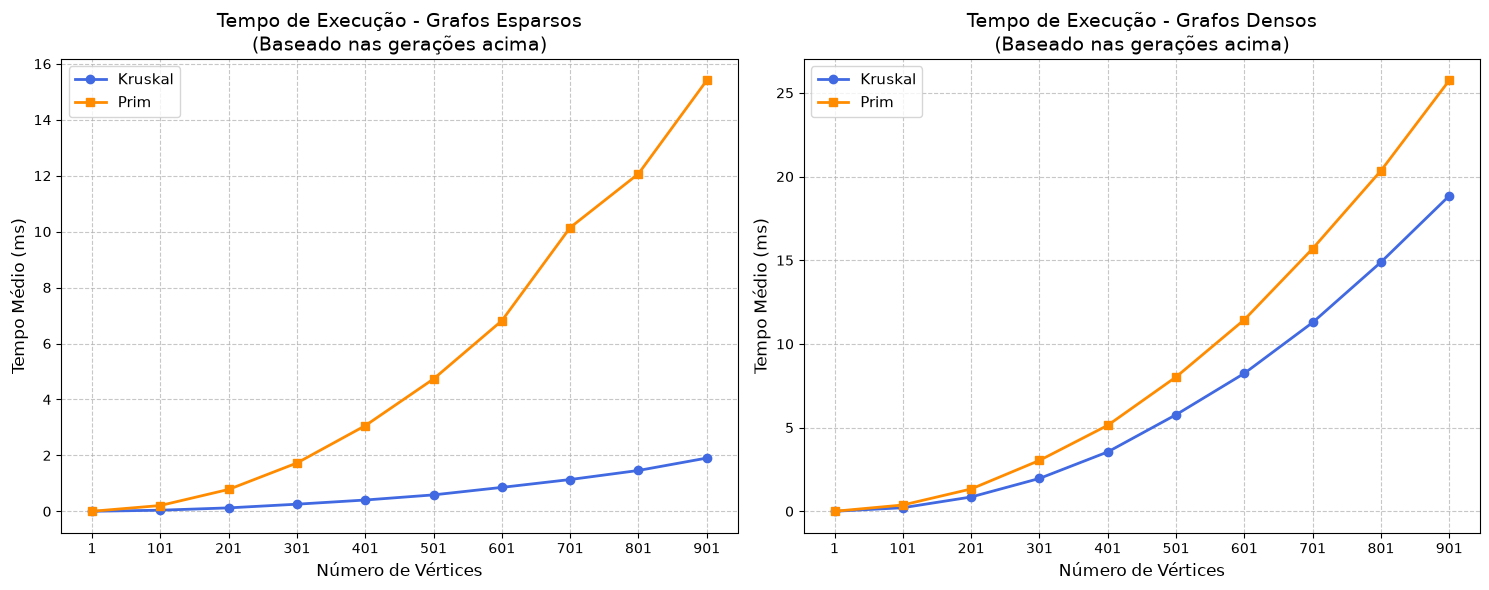

In [12]:
import numpy as np

# Calculando a média dos tempos agrupados por vértice
medias_esp_kru = [np.mean(tempos_historico["Esparso"]["Kruskal"][v]) for v in valores_vertices]
medias_esp_pri = [np.mean(tempos_historico["Esparso"]["Prim"][v]) for v in valores_vertices]
medias_den_kru = [np.mean(tempos_historico["Denso"]["Kruskal"][v]) for v in valores_vertices]
medias_den_pri = [np.mean(tempos_historico["Denso"]["Prim"][v]) for v in valores_vertices]

# Plotando os resultados
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico 1: Grafos Esparsos
ax1.plot(valores_vertices, medias_esp_kru, label='Kruskal', marker='o', color='royalblue', linewidth=2)
ax1.plot(valores_vertices, medias_esp_pri, label='Prim', marker='s', color='darkorange', linewidth=2)
ax1.set_title('Tempo de Execução - Grafos Esparsos\n(Baseado nas gerações acima)', fontsize=14)
ax1.set_xlabel('Número de Vértices', fontsize=12)
ax1.set_ylabel('Tempo Médio (ms)', fontsize=12)
ax1.set_xticks(valores_vertices)
ax1.legend(fontsize=11)
ax1.grid(True, linestyle='--', alpha=0.7)

# Gráfico 2: Grafos Densos
ax2.plot(valores_vertices, medias_den_kru, label='Kruskal', marker='o', color='royalblue', linewidth=2)
ax2.plot(valores_vertices, medias_den_pri, label='Prim', marker='s', color='darkorange', linewidth=2)
ax2.set_title('Tempo de Execução - Grafos Densos\n(Baseado nas gerações acima)', fontsize=14)
ax2.set_xlabel('Número de Vértices', fontsize=12)
ax2.set_ylabel('Tempo Médio (ms)', fontsize=12)
ax2.set_xticks(valores_vertices)
ax2.legend(fontsize=11)
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### 1. Modelagem do Problema

O experimento foi modelado como uma comparação empírica de complexidade entre dois 
algoritmos clássicos de MST — **Kruskal** e **Prim** — implementados sobre a mesma 
estrutura de dados: **matriz de adjacência**. Diferente de implementações que usam 
listas de adjacência ou heaps, aqui:

- **Kruskal** percorre a matriz para extrair as arestas e depois as ordena;
- **Prim** utiliza **busca linear (naive)** a cada passo para localizar a aresta de 
  menor custo que liga a árvore parcial ao restante dos vértices, em vez de uma fila 
  de prioridades.

Essa escolha de implementação foi deliberada para isolar o efeito da **representação 
por matriz de adjacência** sobre o desempenho, e não o efeito de estruturas de dados 
auxiliares mais sofisticadas (como heaps binários).

### 2. Análise dos Algoritmos e Complexidade Computacional

Com matriz de adjacência e busca naive, as complexidades teóricas mudam em relação 
às versões "clássicas" otimizadas:

- **Kruskal (matriz + ordenação):** extrair as arestas da matriz custa 
  $O(V^2)$, e ordená-las custa $O(E \log E)$, com 
  $E \leq V^2 / 2$. No pior caso (grafo denso), isso se aproxima de 
  $O(V^2 \log V)$.
- **Prim (matriz + busca naive):** a cada uma das $V$ iterações, uma busca linear 
  percorre até $O(V)$ candidatos para encontrar a menor aresta, resultando 
  em $O(V^2)$ no total — **independente da densidade do grafo**.

Essa diferença é a chave da comparação: como o Prim naive tem custo fixo 
$O(V^2)$, ele tende a ser **relativamente mais estável** conforme o grafo 
fica mais denso, enquanto o Kruskal sofre mais com o crescimento do número de 
arestas, já que sua etapa de ordenação escala com $E$.

### 3. Conclusão e Resultados Obtidos

A comparação experimental é coerente com a análise teórica considerando as 
implementações baseadas em **matriz de adjacência**: em grafos **esparsos**, o custo 
de ordenação do Kruskal é pequeno (poucas arestas), favorecendo-o; já em grafos 
**densos**, o número de arestas cresce quadraticamente e penaliza o Kruskal, enquanto 
o Prim, com sua busca naive de custo fixo $O(V^2)$, tende a se manter mais 
competitivo — mostrando que a escolha do algoritmo depende diretamente da densidade 
do grafo, mesmo quando ambos usam a mesma estrutura de dados de base.